<a href="https://colab.research.google.com/github/Ygorca125/Analise_Obesidade/blob/main/Analise_Obesidade.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('/content/Obesity.csv')

# EDA

In [3]:
df.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [4]:
df.isnull().sum()

,0
Gender,0
Age,0
Height,0
Weight,0
family_history,0
FAVC,0
FCVC,0
NCP,0
CAEC,0
SMOKE,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 17 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          2111 non-null   object 
 1   Age             2111 non-null   float64
 2   Height          2111 non-null   float64
 3   Weight          2111 non-null   float64
 4   family_history  2111 non-null   object 
 5   FAVC            2111 non-null   object 
 6   FCVC            2111 non-null   float64
 7   NCP             2111 non-null   float64
 8   CAEC            2111 non-null   object 
 9   SMOKE           2111 non-null   object 
 10  CH2O            2111 non-null   float64
 11  SCC             2111 non-null   object 
 12  FAF             2111 non-null   float64
 13  TUE             2111 non-null   float64
 14  CALC            2111 non-null   object 
 15  MTRANS          2111 non-null   object 
 16  Obesity         2111 non-null   object 
dtypes: float64(8), object(9)
memory u

In [6]:
df["BMI"] = (df["Weight"] / (df["Height"] ** 2)).round(2)

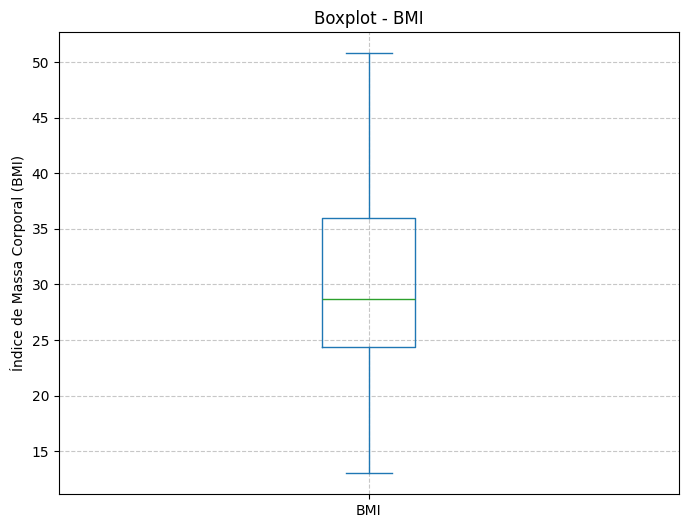

In [7]:
#Avaliar como está a dispersão do BMI (Body Mass Index)

import matplotlib.pyplot as plt


df['BMI'].plot(kind='box', figsize=(8, 6))

plt.title('Boxplot - BMI')
plt.ylabel('Índice de Massa Corporal (BMI)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [8]:
#Verificar se existe relação da coluna Obesity com BMI para evitar vazamento de dados
df.groupby("Obesity")["BMI"].mean()

,BMI
Obesity,
Insufficient_Weight,17.404412
Normal_Weight,22.014216
Obesity_Type_I,32.255670
Obesity_Type_II,36.723266
Obesity_Type_III,42.273920
Overweight_Level_I,25.990241
Overweight_Level_II,28.215310


Vou verificado que o BMI não iria mudar muita coisa, apenas seria uma feature a mais que causaria vazamento de dados em nosso desenvolvimento, então é melhor retirar ela e deixar apenas a coluna Obesity.

In [9]:
#Removendo a coluna BMI e Weight para evitar vazamento de dados
df = df.drop(columns=['BMI', 'Weight'])

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2111 entries, 0 to 2110
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Gender          2111 non-null   object 
 1   Age             2111 non-null   float64
 2   Height          2111 non-null   float64
 3   family_history  2111 non-null   object 
 4   FAVC            2111 non-null   object 
 5   FCVC            2111 non-null   float64
 6   NCP             2111 non-null   float64
 7   CAEC            2111 non-null   object 
 8   SMOKE           2111 non-null   object 
 9   CH2O            2111 non-null   float64
 10  SCC             2111 non-null   object 
 11  FAF             2111 non-null   float64
 12  TUE             2111 non-null   float64
 13  CALC            2111 non-null   object 
 14  MTRANS          2111 non-null   object 
 15  Obesity         2111 non-null   object 
dtypes: float64(7), object(9)
memory usage: 264.0+ KB


In [11]:
#Transformar as váriaveis categoricas em numericas e transformar em colunas em categoricas usando OneHotEncoder além de usar StandartScaler para as variáveis numericas
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_features = [
    'Age', 'Height',
    'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE'
]

categorical_features = [
    'Gender', 'family_history', 'FAVC',
    'CAEC', 'SMOKE', 'SCC', 'CALC', 'MTRANS'
]


preprocessor = ColumnTransformer(
    transformers=[

        ('num', StandardScaler(), numeric_features),

        ('cat', OneHotEncoder(
            handle_unknown='ignore',
            drop='first',
            sparse_output=False
        ), categorical_features)
    ],


    remainder='drop'
)


print(f"   → {len(numeric_features)} colunas numéricas serão escaladas")
print(f"   → {len(categorical_features)} colunas categóricas serão one-hot encoded")

   → 7 colunas numéricas serão escaladas
   → 8 colunas categóricas serão one-hot encoded


In [12]:
  X = df.drop(columns=['Obesity'])
y = df['Obesity']

X_processed = preprocessor.fit_transform(X)

feature_names = preprocessor.get_feature_names_out()
X_processed_df = pd.DataFrame(X_processed, columns=feature_names)

print("Shape final:", X_processed_df.shape)

pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

display(X_processed_df.head())

Shape final: (2111, 22)


,num__Age,num__Height,num__FCVC,num__NCP,num__CH2O,num__FAF,num__TUE,cat__Gender_Male,cat__family_history_yes,cat__FAVC_yes,cat__CAEC_Frequently,cat__CAEC_Sometimes,cat__CAEC_no,cat__SMOKE_yes,cat__SCC_yes,cat__CALC_Frequently,cat__CALC_Sometimes,cat__CALC_no,cat__MTRANS_Bike,cat__MTRANS_Motorbike,cat__MTRANS_Public_Transportation,cat__MTRANS_Walking
0,-0.522124,-0.875589,-0.785019,0.404153,-0.013073,-1.188039,0.561997,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
1,-0.522124,-1.947599,1.088342,0.404153,1.618759,2.339750,-1.080625,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
2,-0.206889,1.054029,-0.785019,0.404153,-0.013073,1.163820,0.561997,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
3,0.423582,1.054029,1.088342,0.404153,-0.013073,1.163820,-1.080625,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
4,-0.364507,0.839627,-0.785019,-2.167023,-0.013073,-1.188039,-1.080625,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0


In [13]:
y.head()

,Obesity
0,Normal_Weight
1,Normal_Weight
2,Normal_Weight
3,Overweight_Level_I
4,Overweight_Level_II


In [14]:
# Mapeamento manual das classes
class_mapping = {
    'Insufficient_Weight': 0,
    'Normal_Weight': 1,
    'Overweight_Level_I': 2,
    'Overweight_Level_II': 3,
    'Obesity_Type_I': 4,
    'Obesity_Type_II': 5,
    'Obesity_Type_III': 6
}


y_encoded = y.map(class_mapping)

print("Classes mapeadas:")
print(y_encoded.value_counts().sort_index())

inverse_mapping = {v: k for k, v in class_mapping.items()}
print("\nMapeamento inverso:")
for num, nome in inverse_mapping.items():
    print(f"{num} → {nome}")

Classes mapeadas:
Obesity
0    272
1    287
2    290
3    290
4    351
5    297
6    324
Name: count, dtype: int64

Mapeamento inverso:
0 → Insufficient_Weight
1 → Normal_Weight
2 → Overweight_Level_I
3 → Overweight_Level_II
4 → Obesity_Type_I
5 → Obesity_Type_II
6 → Obesity_Type_III


#Modelo XGBoost 88%

In [15]:
from sklearn.model_selection import RandomizedSearchCV, train_test_split
from sklearn.metrics import accuracy_score, classification_report
import xgboost as xgb
import time
import numpy as np


class_mapping = {
    'Insufficient_Weight': 0, 'Normal_Weight': 1, 'Overweight_Level_I': 2,
    'Overweight_Level_II': 3, 'Obesity_Type_I': 4, 'Obesity_Type_II': 5,
    'Obesity_Type_III': 6
}

y_encoded = y.map(class_mapping)

X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

param_dist = {
    'n_estimators': [400, 600],
    'max_depth': [4, 6],
    'learning_rate': [0.05],
    'subsample': [0.75, 0.85],
    'colsample_bytree': [0.7, 0.8],
    'min_child_weight': [1, 5]
}

xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=7,
    eval_metric='mlogloss',
    random_state=42,
    verbosity=0
)

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=40,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=2
)



random_search.fit(X_train, y_train)

print("\n Melhores Parâmetros:")
print(random_search.best_params_)

print(f"\n Melhor Acurácia (média CV 5 folds): {random_search.best_score_:.4f}")

print("\n Acurácias por Fold - Melhor configuração:")
best_index = random_search.best_index_

fold_scores = [
    random_search.cv_results_[f'split{i}_test_score'][best_index]
    for i in range(5)
]

for i, score in enumerate(fold_scores, 1):
    print(f"   Fold {i}: {score:.4f}")

print(f"\n Resumo:")
print(f"   Média:          {np.mean(fold_scores):.4f}")
print(f"   Desvio padrão:  {np.std(fold_scores):.4f}")
print(f"   Melhor fold:    {max(fold_scores):.4f}")
print(f"   Pior fold:      {min(fold_scores):.4f}")



Fitting 5 folds for each of 32 candidates, totalling 160 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 32 is smaller than n_iter=40. Running 32 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(



 Melhores Parâmetros:
{'subsample': 0.85, 'n_estimators': 400, 'min_child_weight': 1, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.8}

 Melhor Acurácia (média CV 5 folds): 0.8756

 Acurácias por Fold - Melhor configuração:
   Fold 1: 0.8698
   Fold 2: 0.8817
   Fold 3: 0.8817
   Fold 4: 0.8872
   Fold 5: 0.8576

 Resumo:
   Média:          0.8756
   Desvio padrão:  0.0107
   Melhor fold:    0.8872
   Pior fold:      0.8576


 Acurácia no Teste (hold-out): 0.8794

                     precision    recall  f1-score   support

Insufficient_Weight     0.9608    0.9074    0.9333        54
      Normal_Weight     0.6944    0.8621    0.7692        58
 Overweight_Level_I     0.8800    0.7586    0.8148        58
Overweight_Level_II     0.8947    0.8793    0.8870        58
     Obesity_Type_I     0.8676    0.8429    0.8551        70
    Obesity_Type_II     0.9032    0.9333    0.9180        60
   Obesity_Type_III     1.0000    0.9692    0.9844        65

           accuracy                         0.8794       423
          macro avg     0.8858    0.8790    0.8803       423
       weighted avg     0.8866    0.8794    0.8809       423



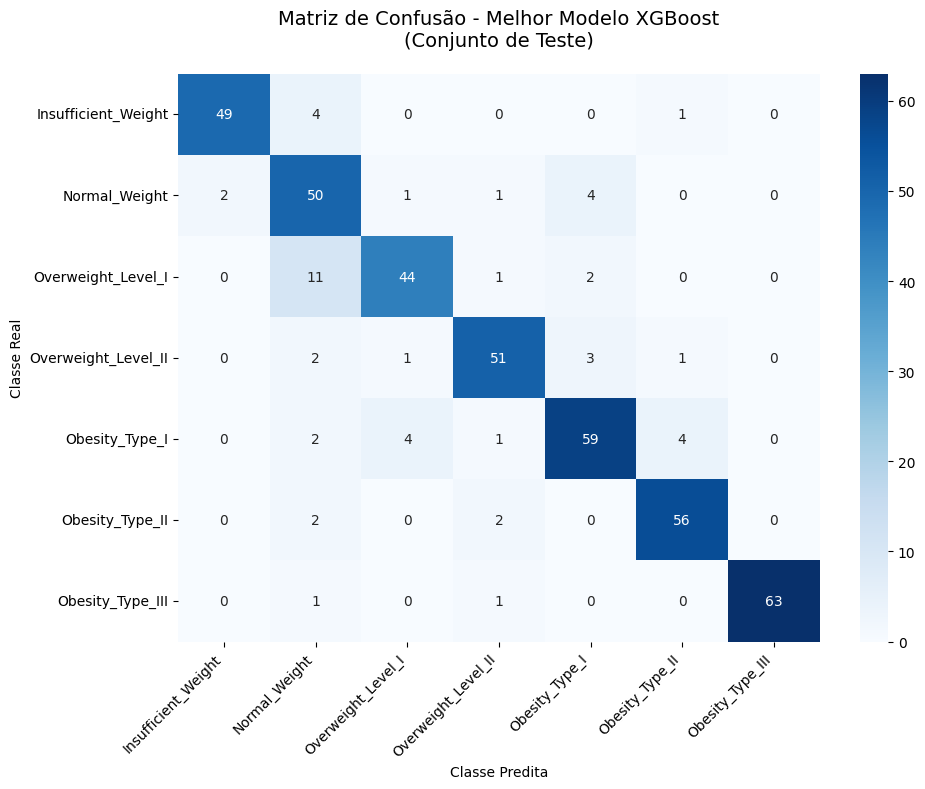

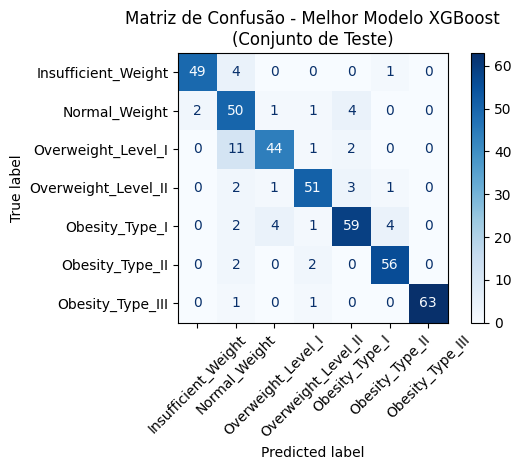

In [16]:

best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)


print(f" Acurácia no Teste (hold-out): {accuracy_score(y_test, y_pred):.4f}\n")

print(classification_report(y_test, y_pred,
                            target_names=list(class_mapping.keys()),
                            digits=4))

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, y_pred)

class_names = list(class_mapping.keys())

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names,
            yticklabels=class_names)
plt.title('Matriz de Confusão - Melhor Modelo XGBoost\n(Conjunto de Teste)', fontsize=14, pad=20)
plt.xlabel('Classe Predita')
plt.ylabel('Classe Real')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, values_format='d', xticks_rotation=45)
plt.title('Matriz de Confusão - Melhor Modelo XGBoost\n(Conjunto de Teste)')
plt.tight_layout()
plt.show()

# Random Forest Classifier 84%


In [17]:
from sklearn.model_selection import RandomizedSearchCV
import xgboost as xgb


param_dist = {
    'n_estimators': [400, 600],
    'max_depth': [4, 6],
    'learning_rate': [0.05],
    'subsample': [0.75, 0.85],
    'colsample_bytree': [0.7, 0.8],
    'min_child_weight': [1, 5]
}

xgb_model = xgb.XGBClassifier(
    objective='multi:softmax',
    num_class=7,
    eval_metric='mlogloss',
    random_state=42,
    verbosity=0
)

random_search = RandomizedSearchCV(
    estimator=xgb_model,
    param_distributions=param_dist,
    n_iter=40,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=2
)

random_search.fit(X_train, y_train)


best_model_xg = random_search.best_estimator_

print("\n XGBoost treinado com sucesso!")
print("Melhor acurácia CV:", random_search.best_score_)
print("Tipo do modelo:", type(best_model_xg).__name__)

/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 32 is smaller than n_iter=40. Running 32 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Fitting 5 folds for each of 32 candidates, totalling 160 fits

 XGBoost treinado com sucesso!
Melhor acurácia CV: 0.8755886432672554
Tipo do modelo: XGBClassifier


In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV


param_grid = {
    'n_estimators': [300, 700],
    'max_depth': [6, 10],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt', 'log2'],
    'bootstrap': [True]
}

rf = RandomForestClassifier(random_state=42, n_jobs=-1)

grid_search_rf = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=2
)

grid_search_rf.fit(X_train, y_train)

best_rf_model = grid_search_rf.best_estimator_


print("Melhor acurácia CV:", grid_search_rf.best_score_)

Fitting 5 folds for each of 32 candidates, totalling 160 fits
Melhor acurácia CV: 0.8501237862799151


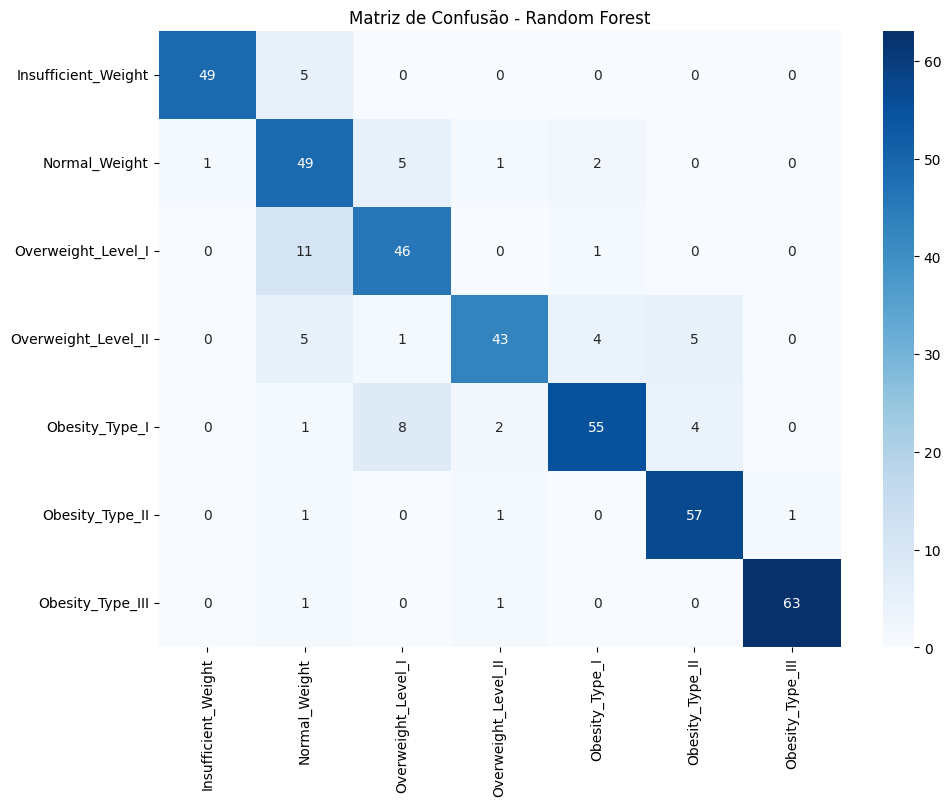

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
import numpy as np

y_pred = best_rf_model.predict(X_test)

inverse_mapping = {v: k for k, v in class_mapping.items()}
y_test_names = np.array([inverse_mapping[i] for i in y_test])
y_pred_names = np.array([inverse_mapping[i] for i in y_pred])

cm = confusion_matrix(y_test_names, y_pred_names, labels=list(class_mapping.keys()))

plt.figure(figsize=(11, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_mapping.keys(),
            yticklabels=class_mapping.keys())
plt.title('Matriz de Confusão - Random Forest')
plt.show()

# Regressão Logística 60%

In [20]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import classification_report, accuracy_score
import time
import numpy as np

print("Iniciando RandomizedSearchCV para Regressão Logística (Versão Corrigida)...\n")

param_dist = {
    'C': [0.01, 0.1, 50],
    'penalty': ['l2', None],
    'solver': ['lbfgs', 'saga'],
    'max_iter': [1000, 2000]
}

log_reg = LogisticRegression(
    multi_class='multinomial',
    random_state=42,
    n_jobs=-1
)

random_search = RandomizedSearchCV(
    estimator=log_reg,
    param_distributions=param_dist,
    n_iter=50,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    random_state=42,
    verbose=1,
    error_score='raise'
)

random_search.fit(X_train, y_train)

print("\n Melhores Parâmetros:")
print(random_search.best_params_)

print(f"\n Melhor Acurácia (média CV 5 folds): {random_search.best_score_:.4f}")

print("\n Acurácias por Fold - Melhor configuração:")
best_index = random_search.best_index_

fold_scores = [
    random_search.cv_results_[f'split{i}_test_score'][best_index]
    for i in range(5)
]

for i, score in enumerate(fold_scores, 1):
    print(f"   Fold {i}: {score:.4f}")

print(f"\n Resumo:")
print(f"   Média:          {np.mean(fold_scores):.4f}")
print(f"   Desvio padrão:  {np.std(fold_scores):.4f}")
print(f"   Melhor fold:    {max(fold_scores):.4f}")
print(f"   Pior fold:      {min(fold_scores):.4f}")

best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test)

print("\n" + "="*60)
print(" AVALIAÇÃO FINAL NO CONJUNTO DE TESTE (20%)")
print(f" Acurácia no Teste (hold-out): {accuracy_score(y_test, y_pred):.4f}")
print("="*60)

print("\n Relatório de Classificação (Teste):")
print(classification_report(y_test, y_pred,
                            target_names=list(class_mapping.keys()),
                            digits=4))

Iniciando RandomizedSearchCV para Regressão Logística (Versão Corrigida)...

Fitting 5 folds for each of 24 candidates, totalling 120 fits


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 24 is smaller than n_iter=50. Running 24 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



 Melhores Parâmetros:
{'solver': 'lbfgs', 'penalty': 'l2', 'max_iter': 1000, 'C': 50}

 Melhor Acurácia (média CV 5 folds): 0.6185

 Acurácias por Fold - Melhor configuração:
   Fold 1: 0.6065
   Fold 2: 0.6538
   Fold 3: 0.6095
   Fold 4: 0.6113
   Fold 5: 0.6113

 Resumo:
   Média:          0.6185
   Desvio padrão:  0.0178
   Melhor fold:    0.6538
   Pior fold:      0.6065

 AVALIAÇÃO FINAL NO CONJUNTO DE TESTE (20%)
 Acurácia no Teste (hold-out): 0.6217

 Relatório de Classificação (Teste):
                     precision    recall  f1-score   support

Insufficient_Weight     0.6230    0.7037    0.6609        54
      Normal_Weight     0.5952    0.4310    0.5000        58
 Overweight_Level_I     0.4583    0.3793    0.4151        58
Overweight_Level_II     0.6207    0.3103    0.4138        58
     Obesity_Type_I     0.5000    0.5857    0.5395        70
    Obesity_Type_II     0.5957    0.9333    0.7273        60
   Obesity_Type_III     0.9403    0.9692    0.9545        65

         

In [21]:
print(" Melhores Parâmetros:")
print(random_search.best_params_)

print(f"\n Melhor Acurácia (CV 5 folds): {random_search.best_score_:.4f}")

best_log_model = random_search.best_estimator_

 Melhores Parâmetros:
{'solver': 'lbfgs', 'penalty': 'l2', 'max_iter': 1000, 'C': 50}

 Melhor Acurácia (CV 5 folds): 0.6185


In [22]:
print(" Melhores Parâmetros:")
print(random_search.best_params_)

print(f"\n Melhor Acurácia (média 5-Fold CV): {random_search.best_score_:.4f}")

best_log_model = random_search.best_estimator_

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y_encoded,
    test_size=0.2, random_state=42, stratify=y_encoded
)

y_pred = best_log_model.predict(X_test)

print(f"\n Acurácia no Conjunto de Teste: {accuracy_score(y_test, y_pred):.4f}")
print("\nRelatório Completo:")
print(classification_report(y_test, y_pred,
                          target_names=class_mapping.keys()))

 Melhores Parâmetros:
{'solver': 'lbfgs', 'penalty': 'l2', 'max_iter': 1000, 'C': 50}

 Melhor Acurácia (média 5-Fold CV): 0.6185

 Acurácia no Conjunto de Teste: 0.6217

Relatório Completo:
                     precision    recall  f1-score   support

Insufficient_Weight       0.62      0.70      0.66        54
      Normal_Weight       0.60      0.43      0.50        58
 Overweight_Level_I       0.46      0.38      0.42        58
Overweight_Level_II       0.62      0.31      0.41        58
     Obesity_Type_I       0.50      0.59      0.54        70
    Obesity_Type_II       0.60      0.93      0.73        60
   Obesity_Type_III       0.94      0.97      0.95        65

           accuracy                           0.62       423
          macro avg       0.62      0.62      0.60       423
       weighted avg       0.62      0.62      0.61       423



# Salvando o modelo

In [23]:
import joblib
import pickle
import os
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_cols = ['Gender', 'family_history', 'FAVC', 'CAEC',
                    'SMOKE', 'SCC', 'CALC', 'MTRANS']
numerical_cols = ['Age', 'Height', 'FCVC', 'NCP', 'CH2O', 'FAF', 'TUE']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore',
                              sparse_output=False,
                              drop='first'),
         categorical_cols)
    ],
    remainder='passthrough'
)

preprocessor.fit(X)

print(" Features geradas:", preprocessor.transform(X.head(1)).shape[1])

joblib.dump(preprocessor, "preprocessor.pkl", compress=3)

with open("xgboost_model.pkl", "wb") as f:
    pickle.dump(best_model_xg, f, protocol=4)

with open("class_mapping.pkl", "wb") as f:
    pickle.dump(class_mapping, f, protocol=4)

print(" Salvo com sucesso!")
print(os.listdir())

 Features geradas: 22
 Salvo com sucesso!
['.config', 'preprocessor.pkl', 'xgboost_model.pkl', 'Obesity.csv', 'class_mapping.pkl', 'sample_data']
